In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
from scipy.optimize import curve_fit

# Repo root (walk up to .git so this works from any CWD)
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / '.git').exists():
    REPO_ROOT = REPO_ROOT.parent


In [ ]:
def get_data_to_plot_alphas_2(n, noise_type, gamma, method_type='hypergraph', stat_type='stats', ml_alpha_pattern='all_ones'):
    """
    Load the standardized algo_data_merged file for given (n, noise_type, gamma)
    from the new paper_data_2 directory.
    For method_type='ml', ml_alpha_pattern can be 'all_ones' or 'half_ones' to load the corresponding alpha variant.
    """
    general_dir = REPO_ROOT / "data" / "paper_data_2" / method_type
    fold = general_dir / f"{n}/{stat_type}"

    suffix = ""
    if method_type == 'ml' and ml_alpha_pattern == 'half_ones':
        suffix = "_half_ones"

    if stat_type == 'stats':
        mean_file = fold / f"alphas_means_{noise_type}_{gamma}{suffix}.npy"
        lower_file = fold / f"alphas_stds_lower_{noise_type}_{gamma}{suffix}.npy"
        higher_file = fold / f"alphas_stds_higher_{noise_type}_{gamma}{suffix}.npy"
    elif stat_type == 'iqr':
        mean_file = fold / f"alphas_medians_{noise_type}_{gamma}{suffix}.npy"
        lower_file = fold / f"alphas_iqrs_1_{noise_type}_{gamma}{suffix}.npy"
        higher_file = fold / f"alphas_iqrs_3_{noise_type}_{gamma}{suffix}.npy"
    else:
        raise ValueError("stat_type must be either 'stats' or 'iqr'")

    if not mean_file.exists():
        raise FileNotFoundError(f"No file found at {mean_file}")
    if not lower_file.exists():
        raise FileNotFoundError(f"No file found at {lower_file}")
    if not higher_file.exists():
        raise FileNotFoundError(f"No file found at {higher_file}")

    mean_data = np.load(mean_file)
    lower_data = np.load(lower_file)
    higher_data = np.load(higher_file)

    yerr = [lower_data, higher_data]
    return mean_data, yerr


In [3]:
def sigmoid_base2(k, m, x0):
    """Base-2 sigmoid: 0.5 + 0.5 / (1 + 2^(-(m*k + x0)))."""
    exponent = np.clip(-(m * k + x0), -100, 100)
    return 0.5 + 0.5 / (1.0 + 2.0**exponent)

def fit_sigmoid_and_line(k_vals, y_vals, k_line, use_elbow=True):
    """
    Fit sigmoid to (k_vals, y_vals). If use_elbow, restrict to inclusive elbow range.
    Returns (k_line, y_fit) or None if fit fails.
    """
    k_vals = np.asarray(k_vals)
    y_vals = np.asarray(y_vals)
    if use_elbow and len(y_vals) >= 4:
        breakout = np.where(y_vals > 0.55)[0]
        plateau = np.where(y_vals >= 0.99)[0]
        start = max(0, breakout[0] - 1) if len(breakout) > 0 else 0
        end = plateau[0] if len(plateau) > 0 else len(y_vals) - 1
        if start >= end:
            start, end = 0, len(y_vals) - 1
        valid = np.arange(start, end + 1)
        if len(valid) < 2:
            valid = np.arange(len(y_vals))
    else:
        valid = np.arange(len(y_vals))
    k_fit = k_vals[valid]
    y_fit_vals = y_vals[valid]
    sigma = np.clip(np.abs(y_fit_vals - 0.5) + 0.05, 0.05, None)
    try:
        popt, _ = curve_fit(
            sigmoid_base2, k_fit, y_fit_vals,
            p0=[10.0, -10.0], sigma=sigma, absolute_sigma=False, maxfev=10000,
            bounds=([0.0, -np.inf], [np.inf, np.inf])
        )
        y_line = sigmoid_base2(k_line, popt[0], popt[1])
        return y_line
    except (RuntimeError, ValueError):
        return None

In [ ]:
def get_ml_data_from_ml_data_folder(n, noise_type, gamma, ml_alpha_pattern='all_ones'):
    """
    Load ML alpha accuracy from ml_data folder (scenario1_train_results.json).
    ml_alpha_pattern: 'all_ones' or 'half_ones'.
    Returns (k_vals, y_vals, yerr_lo, yerr_hi) with 7 points per run (k ≈ 1.4..2.0).
    """
    # Map paper noise names to ml_data channel_type
    channel_type = 'thermal' if noise_type == 'relaxation' else noise_type  # dephasing, depolarizing
    # Experiment folder by n and alpha pattern
    if n <= 10:
        q_suffix = 'q_5_10'
    else:
        q_suffix = 'q_11_12'
    if ml_alpha_pattern == 'all_ones':
        exp_name = f"exp_s1_fixed_alpha_all_ones_fixed_y_all_zeros_{q_suffix}"
    else:
        exp_name = f"exp_s1_fixed_alpha_half_ones_leading_fixed_y_all_zeros_{q_suffix}"
    results_file = REPO_ROOT / "data" / "ml_data" / exp_name / "scenario1_train_results.json"
    if not results_file.exists():
        raise FileNotFoundError(f"Not found: {results_file}")
    with open(results_file) as f:
        data = json.load(f)
    # Find run matching (n, channel_type, strength)
    for run in data['runs']:
        meta = run['meta']
        if meta['n'] != n:
            continue
        cc = meta['channel_config']
        if cc['type'] != channel_type or cc['strength'] != gamma:
            continue
        k_list, y_list, lo_list, hi_list = [], [], [], []
        for per in run['per_nps']:
            nps = per['nps']
            k_list.append(np.log2(nps) / n)
            accs = [r['logreg']['val']['acc'] for r in per['independent_runs']['per_run']]
            med = float(np.median(accs))
            q1, q3 = np.percentile(accs, [25, 75])
            y_list.append(med)
            lo_list.append(med - q1)  # error bar below
            hi_list.append(q3 - med)  # error bar above
        return np.array(k_list), np.array(y_list), np.array(lo_list), np.array(hi_list)


In [5]:
def plot_method_centric_raw_curves(gamma=0.1, stat_type='iqr'):
    """
    4x1 grid: raw data with lines connecting points. x-axis k in [1, 2].
    Uses single_column.mplstyle; legend above; method name lower right; ylabel A_MF(n_c).
    """
    plt.style.use(str(REPO_ROOT / 'manuscript' / 'figures_notebooks' / 'single_column.mplstyle'))
    noise_types = [
        ('dephasing', plt.cm.Blues),
        ('relaxation', plt.cm.Reds),
        ('depolarizing', plt.cm.Greens)
    ]
    n_qubits_heur = [5, 6, 7, 8, 9, 10, 11, 13, 15]
    n_qubits_ml = [5, 6, 7, 8, 9, 10, 11, 12]
    k_target = np.array([0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1])
    k_mask = (k_target >= 1) & (k_target <= 2)

    methods = [
        ('hypergraph', n_qubits_heur, '(a)', 'Hypergraph'),
        ('shadow_surrogates', n_qubits_heur, '(b)', 'Eigenshadow'),
        ('ml_all_ones', n_qubits_ml, '(c)', r'ML ($|\alpha| = n_q$)'),
        ('ml_half_ones', n_qubits_ml, '(d)', r'ML ($|\alpha| = n_q/2$)')
    ]

    fig, axes = plt.subplots(4, 1, figsize=(4, 7), sharex=True, sharey=True)
    # Only bottom axis shows x tick labels (joined by x-axis)
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)

    for idx_m, (m_id, n_list, label, m_name) in enumerate(methods):
        ax = axes[idx_m]
        ax.axhline(0.5, color='black', linestyle='-', alpha=0.3, zorder=1)
        ax.set_xlim(1, 2)

        for noise_type, cmap in noise_types:
            colors = cmap(np.linspace(0.4, 0.9, len(n_list)))
            for idx_n, n in enumerate(n_list):
                c = colors[idx_n]
                lw = 0.5 + 1.3 * (idx_n / max(len(n_list), 1))
                if m_id == 'ml_all_ones':
                    try:
                        k_ml, y_vals, _, _ = get_ml_data_from_ml_data_folder(n, noise_type, gamma, ml_alpha_pattern='all_ones')
                        mask = (k_ml >= 1) & (k_ml <= 2)
                        if np.any(mask):
                            k_plot, y_plot = k_ml[mask], y_vals[mask]
                            ax.plot(k_plot, y_plot, '-o', color=c, markersize=3.5, linewidth=lw, alpha=0.9, zorder=2)
                    except FileNotFoundError:
                        pass
                elif m_id == 'ml_half_ones':
                    try:
                        k_ml, y_vals, _, _ = get_ml_data_from_ml_data_folder(n, noise_type, gamma, ml_alpha_pattern='half_ones')
                        mask = (k_ml >= 1) & (k_ml <= 2)
                        if np.any(mask):
                            k_plot, y_plot = k_ml[mask], y_vals[mask]
                            ax.plot(k_plot, y_plot, '-o', color=c, markersize=3.5, linewidth=lw, alpha=0.9, zorder=2)
                    except FileNotFoundError:
                        pass
                else:
                    try:
                        y_vals, _ = get_data_to_plot_alphas_2(n, noise_type, gamma, m_id, stat_type)
                        k_plot = k_target[k_mask]
                        y_plot = y_vals[k_mask]
                        if len(k_plot) > 0:
                            ax.plot(k_plot, y_plot, '-o', color=c, markersize=3.5, linewidth=lw, alpha=0.9, zorder=2)
                    except FileNotFoundError:
                        pass

        ax.set_ylim(0.48, 1.02)
        ax.set_ylabel(r"$A_{\mathrm{MF}}(n_c)$")
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.text(0.02, 0.92, label, transform=ax.transAxes, va='top')
        if m_id in ('ml_all_ones', 'ml_half_ones'):
            ax.text(0.02, 0.08, m_name, transform=ax.transAxes, fontsize=10, ha='left', va='bottom')
        else:
            ax.text(0.98, 0.08, m_name, transform=ax.transAxes, fontsize=10, ha='right', va='bottom')
    axes[-1].set_xlabel(r"Number of copies exponent $k$, $n_c = 2^{kn_q}$")

    legend_handles = [
        mlines.Line2D([], [], color=plt.cm.Blues(0.7), linestyle='-', linewidth=2, label=r'Dephasing ($\epsilon_p = 0.1$)'),
        mlines.Line2D([], [], color=plt.cm.Reds(0.7), linestyle='-', linewidth=2, label=r'Relaxation ($\epsilon_p = 0.1$)'),
        mlines.Line2D([], [], color=plt.cm.Greens(0.7), linestyle='-', linewidth=2, label=r'Depolarizing ($\epsilon_p = 0.1$)')
    ]
    axes[2].legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(0.1, 1), ncol=1, frameon=True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(str(REPO_ROOT / "manuscript" / "figures_manuscript" / "fig3_measure_first.pdf"), bbox_inches='tight')
    plt.show()


def plot_method_centric_raw_curves_three_gamma(gammas=(0.01, 0.05, 0.1), stat_type='iqr'):
    """
    Extra appendix figure (does not modify the original one): 4x3 grid, one column per gamma.
    Default columns are epsilon_p = 0.01, 0.05, 0.1.
    """
    if len(gammas) != 3:
        raise ValueError("gammas must contain exactly three values for a 4x3 plot")

    plt.style.use(str(REPO_ROOT / 'manuscript' / 'figures_notebooks' / 'single_column.mplstyle'))
    noise_types = [
        ('dephasing', plt.cm.Blues),
        ('relaxation', plt.cm.Reds),
        ('depolarizing', plt.cm.Greens)
    ]
    n_qubits_heur = [5, 6, 7, 8, 9, 10, 11, 13, 15]
    n_qubits_ml = [5, 6, 7, 8, 9, 10, 11, 12]
    k_target = np.array([0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1])
    k_mask = (k_target >= 1) & (k_target <= 2)

    methods = [
        ('hypergraph', n_qubits_heur, 'a)', 'Hypergraph'),
        ('shadow_surrogates', n_qubits_heur, 'b)', 'Eigenshadow'),
        ('ml_all_ones', n_qubits_ml, 'c)', r'ML ($|\alpha| = n_q$)'),
        ('ml_half_ones', n_qubits_ml, 'd)', r'ML ($|\alpha| = n_q/2$)')
    ]

    fig, axes = plt.subplots(4, 3, figsize=(8.5, 5.2), sharex=True, sharey=True)

    for col, gamma in enumerate(gammas):
        for idx_m, (m_id, n_list, _label_unused, m_name) in enumerate(methods):
            ax = axes[idx_m, col]
            ax.axhline(0.5, color='black', linestyle='-', alpha=0.3, zorder=1)
            ax.set_xlim(1, 2)

            for noise_type, cmap in noise_types:
                colors = cmap(np.linspace(0.4, 0.9, len(n_list)))
                for idx_n, n in enumerate(n_list):
                    c = colors[idx_n]
                    lw = 1.2 + 0.8 * (idx_n / max(len(n_list), 1))
                    if m_id == 'ml_all_ones':
                        try:
                            k_ml, y_vals, _, _ = get_ml_data_from_ml_data_folder(n, noise_type, gamma, ml_alpha_pattern='all_ones')
                            mask = (k_ml >= 1) & (k_ml <= 2)
                            if np.any(mask):
                                k_plot, y_plot = k_ml[mask], y_vals[mask]
                                ax.plot(k_plot, y_plot, '-o', color=c, markersize=3.0, linewidth=lw, alpha=0.9, zorder=2)
                        except FileNotFoundError:
                            pass
                    elif m_id == 'ml_half_ones':
                        try:
                            k_ml, y_vals, _, _ = get_ml_data_from_ml_data_folder(n, noise_type, gamma, ml_alpha_pattern='half_ones')
                            mask = (k_ml >= 1) & (k_ml <= 2)
                            if np.any(mask):
                                k_plot, y_plot = k_ml[mask], y_vals[mask]
                                ax.plot(k_plot, y_plot, '-o', color=c, markersize=3.0, linewidth=lw, alpha=0.9, zorder=2)
                        except FileNotFoundError:
                            pass
                    else:
                        try:
                            y_vals, _ = get_data_to_plot_alphas_2(n, noise_type, gamma, m_id, stat_type)
                            k_plot = k_target[k_mask]
                            y_plot = y_vals[k_mask]
                            if len(k_plot) > 0:
                                ax.plot(k_plot, y_plot, '-o', color=c, markersize=3.0, linewidth=lw, alpha=0.9, zorder=2)
                        except FileNotFoundError:
                            pass

            ax.set_ylim(0.48, 1.02)
            ax.grid(True, linestyle='--', alpha=0.4)
            if col == 0:
                ax.set_ylabel(r"$A_{\mathrm{MF}}(n_c)$")
            if m_id in ('ml_all_ones', 'ml_half_ones'):
                ax.text(0.02, 0.85, m_name, transform=ax.transAxes, fontsize=9, ha='left', va='bottom')
            else:
                ax.text(0.98, 0.09, m_name, transform=ax.transAxes, fontsize=9, ha='right', va='bottom')
            if idx_m == 0:
                ax.set_title(rf"$\epsilon_p = {gamma}$", pad=4)

    for col in range(3):
        axes[-1, col].set_xlabel(r"Number of copies exponent $k$, $n_c = 2^{kn_q}$")

    legend_handles = [
        mlines.Line2D([], [], color=plt.cm.Blues(0.7), linestyle='-', linewidth=2, label='Dephasing'),
        mlines.Line2D([], [], color=plt.cm.Reds(0.7), linestyle='-', linewidth=2, label='Relaxation'),
        mlines.Line2D([], [], color=plt.cm.Greens(0.7), linestyle='-', linewidth=2, label='Depolarizing')
    ]
    axes[0, 1].legend(handles=legend_handles, loc='center right', ncol=1, frameon=True)

    plt.tight_layout()
    plt.savefig(str(REPO_ROOT / "manuscript" / "figures_manuscript" / "fig3_measure_first_4x2_extra.pdf"), bbox_inches='tight')
    plt.show()


Bad key axes.grid.alpha in file /Users/krzywdaja/Documents/noisy-learning-advantage-3/figures_notebooks/single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


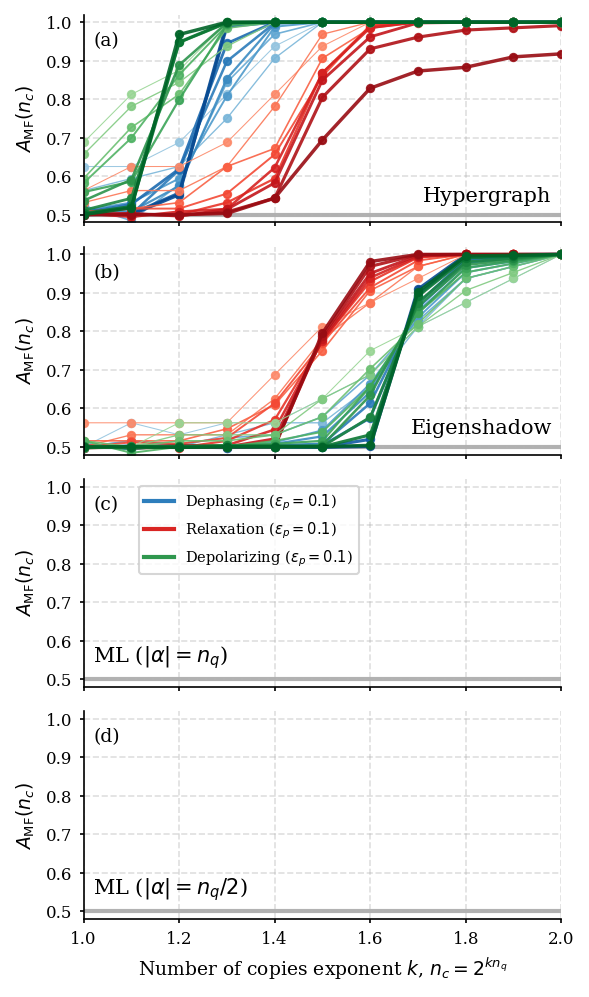

In [6]:
# Example: plot raw data for gamma=0.1
plot_method_centric_raw_curves(gamma=0.1)


Bad key axes.grid.alpha in file /Users/krzywdaja/Documents/noisy-learning-advantage/figures_notebooks/single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


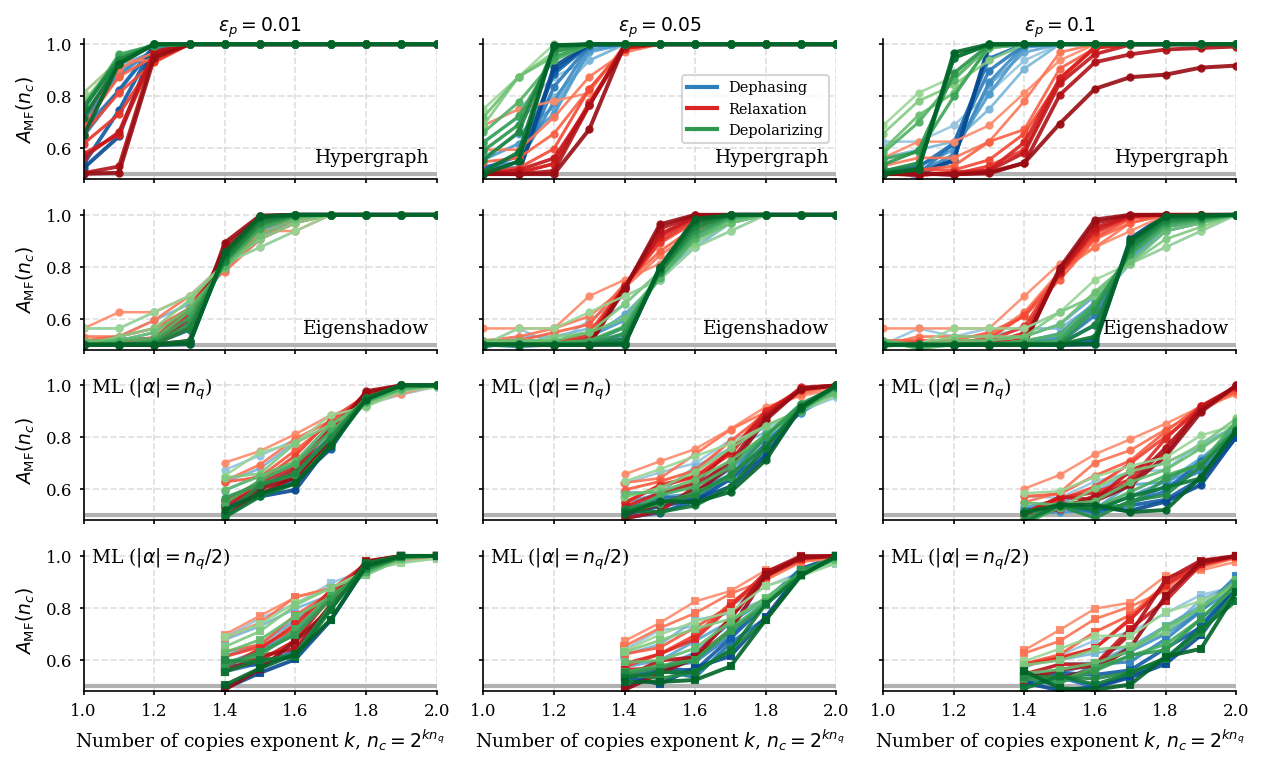

In [79]:
plot_method_centric_raw_curves_three_gamma(gammas=(0.01, 0.05, 0.1))